✅ Dataset saved in /data folder!
📊 Graphs saved in /results folder!


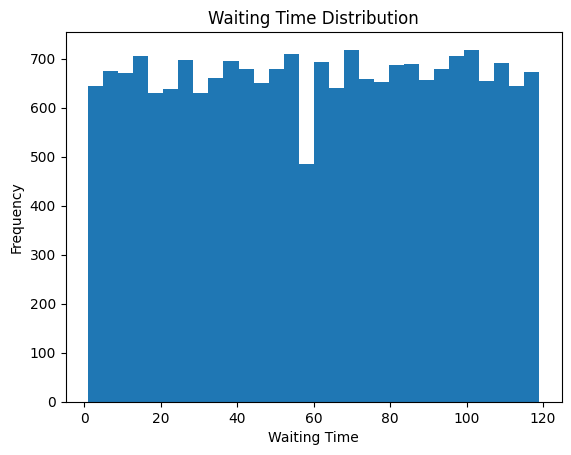

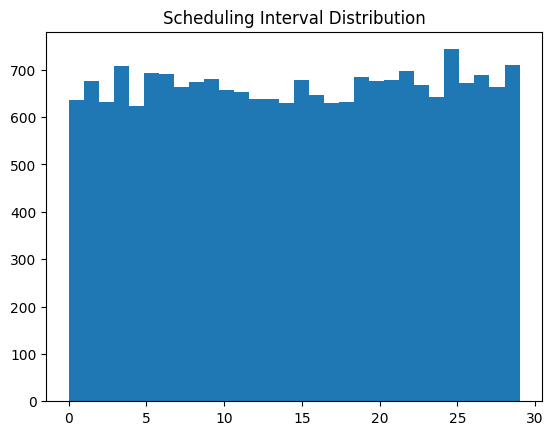

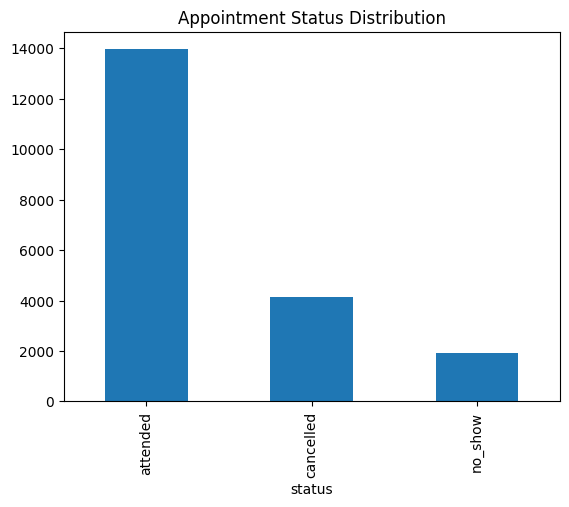

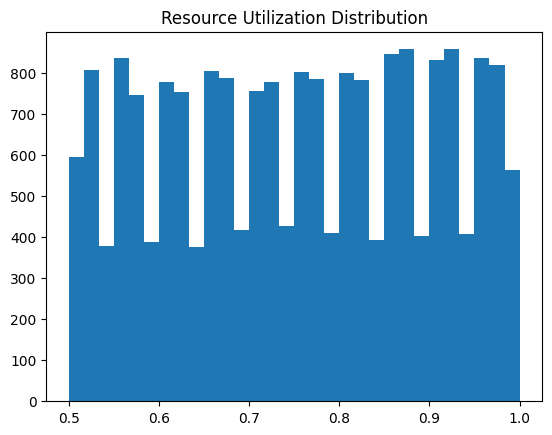

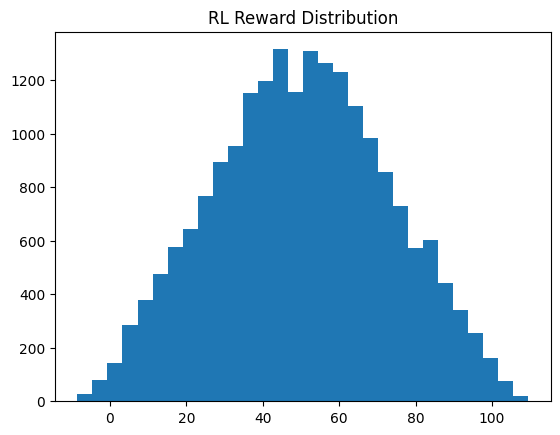

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# SET SEED
# -----------------------------
np.random.seed(42)

# -----------------------------
# PARAMETERS
# -----------------------------
n = 20000

# -----------------------------
# CREATE DATAFRAME
# -----------------------------
df = pd.DataFrame()

# IDs
df['appointment_id'] = np.arange(1, n+1)
df['slot_id'] = np.random.randint(1, 200, n)

# Dates
df['scheduling_date'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, n), unit='D')
df['appointment_date'] = df['scheduling_date'] + pd.to_timedelta(np.random.randint(0, 30, n), unit='D')

# Appointment Time
times = pd.to_datetime(np.random.randint(8*60, 17*60, n), unit='m')
df['appointment_time'] = pd.Series(times).dt.strftime('%H:%M:%S')

# Interval
df['scheduling_interval'] = (df['appointment_date'] - df['scheduling_date']).dt.days

# Status
df['status'] = np.random.choice(
    ['attended', 'cancelled', 'no_show'],
    size=n,
    p=[0.7, 0.2, 0.1]
)

# Check-in Time
df['check_in_time'] = df['appointment_time']
mask = df['status'] == 'attended'

df.loc[mask, 'check_in_time'] = (
    pd.to_datetime(df.loc[mask, 'appointment_time'], format='%H:%M:%S')
    + pd.to_timedelta(np.random.randint(-10, 10, mask.sum()), unit='m')
).dt.strftime('%H:%M:%S')

# Duration
df['appointment_duration'] = np.round(np.random.uniform(5, 60, n), 2)

# Start Time
df['start_time'] = (
    pd.to_datetime(df['appointment_time'], format='%H:%M:%S')
    + pd.to_timedelta(np.random.randint(0, 15, n), unit='m')
).dt.strftime('%H:%M:%S')

# -----------------------------
# ADVANCED FEATURES (RL + HOSPITAL)
# -----------------------------
df['patient_severity'] = np.random.choice(['low','medium','high','critical'], n)
df['doctor_id'] = np.random.randint(1, 20, n)
df['bed_id'] = np.random.randint(1, 100, n)

df['resource_utilization'] = np.round(np.random.uniform(0.5, 1.0, n), 2)
df['waiting_time'] = np.random.randint(1, 120, n)

# Priority logic
df['priority'] = np.where(
    df['patient_severity'].isin(['high','critical']),
    'emergency',
    'normal'
)

# RL Reward
df['reward'] = (
    df['resource_utilization'] * 100
    - df['waiting_time'] * 0.5
    + np.where(df['priority'] == 'emergency', 10, 0)
)

# -----------------------------
# SAVE DATASET TO /data (IMPORTANT FIX)
# -----------------------------
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/hospital_rl_dataset.csv", index=False)

print("✅ Dataset saved in /data folder!")

# -----------------------------
# SAVE GRAPHS TO /results
# -----------------------------
os.makedirs("../results", exist_ok=True)

# 1. Waiting Time
plt.figure()
plt.hist(df['waiting_time'], bins=30)
plt.xlabel("Waiting Time")
plt.ylabel("Frequency")
plt.title("Waiting Time Distribution")
plt.savefig("../results/waiting_time.png")

# 2. Scheduling Interval
plt.figure()
plt.hist(df['scheduling_interval'], bins=30)
plt.title("Scheduling Interval Distribution")
plt.savefig("../results/scheduling_interval.png")

# 3. Status Distribution
plt.figure()
df['status'].value_counts().plot(kind='bar')
plt.title("Appointment Status Distribution")
plt.savefig("../results/status.png")

# 4. Resource Utilization
plt.figure()
plt.hist(df['resource_utilization'], bins=30)
plt.title("Resource Utilization Distribution")
plt.savefig("../results/resource.png")

# 5. Reward Distribution
plt.figure()
plt.hist(df['reward'], bins=30)
plt.title("RL Reward Distribution")
plt.savefig("../results/reward.png")

print("📊 Graphs saved in /results folder!")